# Fundamentals of GenAI — Part 1: How LLMs Work
### Hands-on companion notebook (Santander · Accenture, 2026)

This notebook walks through **Part 1 of the course** — from *"what is a language model"* to
*tokenization, chunking, embeddings and vector databases* — with small, runnable examples.

**How to use this notebook**
- Read the short explanation, then run the **Demo** cell below it and look at the output.
- Each section ends with a **🧪 Try it yourself** cell — a short task for you to complete.

**Sections**
1. What a Language Model Is
2. Evolution of Language Models
3. Transformer Architecture (Self-Attention)
4. LLMs vs SLMs
5. Tokenization
6. Chunking & Context Management
7. Embeddings & Vector Databases

## Setup

We use a handful of well-known **public-domain opening lines** (Pride and Prejudice,
Moby-Dick, A Tale of Two Cities, Frankenstein, Alice in Wonderland, Dracula, Sherlock
Holmes, War and Peace) as our running example corpus, plus one longer public-domain
paragraph (from *Alice's Adventures in Wonderland*) for the chunking section.

Run the cell below once — every later section reuses these variables.

In [1]:
%matplotlib inline
import re
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, Counter

np.random.seed(42)
random.seed(42)

# --- Shared public-domain corpus -------------------------------------------------
ALICE_PARAGRAPH = (
    "Alice was beginning to get very tired of sitting by her sister on the "
    "bank, and of having nothing to do: once or twice she had peeped into the "
    "book her sister was reading, but it had no pictures or conversations in "
    'it, "and what is the use of a book," thought Alice, "without pictures or '
    'conversations?" So she was considering in her own mind (as well as she '
    "could, for the hot day made her feel very sleepy and stupid), whether "
    "the pleasure of making a daisy-chain would be worth the trouble of "
    "getting up and picking the daisies, when suddenly a White Rabbit with "
    "pink eyes ran close by her. There was nothing so very remarkable in "
    "that; nor did Alice think it so very much out of the way to hear the "
    'Rabbit say to itself, "Oh dear! Oh dear! I shall be late!" But when the '
    "Rabbit actually took a watch out of its waistcoat-pocket, and looked at "
    "it, and then hurried on, Alice started to her feet, for it flashed "
    "across her mind that she had never before seen a rabbit with either a "
    "waistcoat-pocket, or a watch to take out of it, and burning with "
    "curiosity, she ran across the field after it."
)

OPENING_LINES = [
    ("Pride and Prejudice", "Jane Austen",
     "It is a truth universally acknowledged, that a single man in possession "
     "of a good fortune must be in want of a wife."),
    ("Moby-Dick", "Herman Melville",
     "Call me Ishmael. Some years ago, having little or no money in my purse, "
     "and nothing particular to interest me on shore, I thought I would sail "
     "about a little and see the watery part of the world."),
    ("A Tale of Two Cities", "Charles Dickens",
     "It was the best of times, it was the worst of times, it was the age of "
     "wisdom, it was the age of foolishness."),
    ("Frankenstein", "Mary Shelley",
     "You will rejoice to hear that no disaster has accompanied the "
     "commencement of an enterprise which you have regarded with such evil "
     "forebodings."),
    ("Alice's Adventures in Wonderland", "Lewis Carroll",
     "Alice was beginning to get very tired of sitting by her sister on the "
     "bank, and of having nothing to do."),
    ("Dracula", "Bram Stoker",
     "Left Munich at 8:35 P.M. on 1st May, arriving at Vienna early next "
     "morning; should have arrived at 6:46, but train was an hour late."),
    ("The Adventures of Sherlock Holmes", "Arthur Conan Doyle",
     "To Sherlock Holmes she is always the woman. I have seldom heard him "
     "mention her under any other name."),
    ("War and Peace", "Leo Tolstoy",
     "Well, Prince, so Genoa and Lucca are now just family estates of the "
     "Buonapartes."),
]

TINY_TRAINING_TEXT = " ".join(t for _, _, t in OPENING_LINES) + " " + ALICE_PARAGRAPH

print(f"Corpus ready: {len(OPENING_LINES)} opening lines, "
      f"{len(TINY_TRAINING_TEXT.split())} words of training text.")

Corpus ready: 8 opening lines, 396 words of training text.


## 1.1 — What a Language Model Is

At its core, a language model is just a system that predicts **the probability of the next
word**, given the words that came before it. Modern LLMs do this with billions of
parameters — but the *idea* is exactly what we can demonstrate with a tiny **bigram model**:
count how often each word is followed by each other word in our corpus, and turn those
counts into probabilities.

**Demo:** build a bigram frequency table from our corpus and ask it "what word comes next?"

In [2]:
def tokenize_words(text):
    return re.findall(r"[A-Za-z']+", text.lower())

words = tokenize_words(TINY_TRAINING_TEXT)

bigram_counts = defaultdict(Counter)
for w1, w2 in zip(words, words[1:]):
    bigram_counts[w1][w2] += 1

def next_word_probs(word, top_n=5):
    counts = bigram_counts.get(word.lower())
    if not counts:
        return {}
    total = sum(counts.values())
    return {w: round(c / total, 2) for w, c in counts.most_common(top_n)}

for seed in ["it", "alice", "the", "she"]:
    print(f"{seed!r:8} -> {next_word_probs(seed)}")

'it'     -> {'was': 0.36, 'and': 0.27, 'is': 0.09, 'had': 0.09, 'so': 0.09}
'alice'  -> {'was': 0.4, 'without': 0.2, 'think': 0.2, 'started': 0.2}
'the'    -> {'age': 0.1, 'bank': 0.1, 'rabbit': 0.1, 'watery': 0.05, 'world': 0.05}
'she'    -> {'had': 0.33, 'is': 0.17, 'was': 0.17, 'could': 0.17, 'ran': 0.17}


This *is* a language model — a very small, very literal-minded one. It only ever looks one
word back, so it can't capture long-range meaning (that's what Transformers fix — see
Section 1.3). But the underlying question — *"given what came before, what comes next?"* —
is the same question GPT-4 and Claude are answering, just with far more context and far more
sophisticated math.

### 🧪 Try it yourself
Pick a different seed word from the corpus (e.g. `"of"`, `"was"`, `"a"`) and print its
next-word probabilities. Does a common word like `"the"` have a more spread-out or more
concentrated distribution than a rare word like `"alice"`? Why do you think that is?

In [3]:
# TODO: pick your own seed word and print its next-word probabilities
# your_seed = "of"
# print(next_word_probs(your_seed))

## 1.2 — Evolution of Language Models

No code needed here — just a quick visual reminder of the milestones from the deck, so the
architecture we build next (Transformers) is anchored in its historical context.

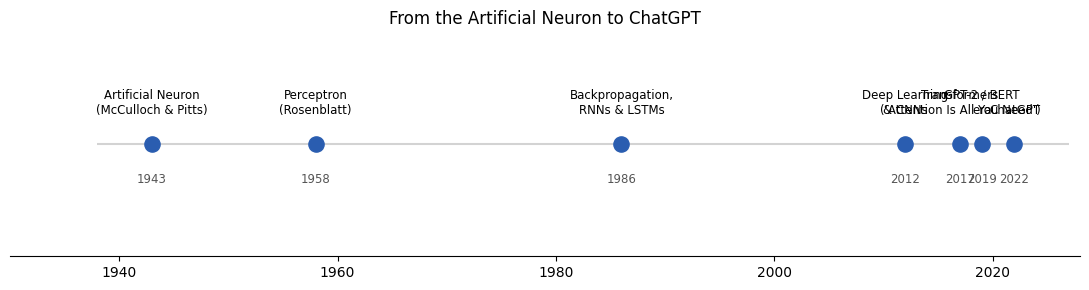

In [4]:
milestones = [
    (1943, "Artificial Neuron\n(McCulloch & Pitts)"),
    (1958, "Perceptron\n(Rosenblatt)"),
    (1986, "Backpropagation,\nRNNs & LSTMs"),
    (2012, "Deep Learning\n& CNNs"),
    (2017, "Transformers\n('Attention Is All You Need')"),
    (2019, "GPT-2 / BERT\nera"),
    (2022, "ChatGPT"),
]

years = [m[0] for m in milestones]
labels = [m[1] for m in milestones]

fig, ax = plt.subplots(figsize=(11, 3))
ax.hlines(1, min(years) - 5, max(years) + 5, color="lightgray", zorder=1)
ax.scatter(years, [1] * len(years), s=120, color="#2a5db0", zorder=2)

for y, label in zip(years, labels):
    ax.annotate(label, (y, 1), xytext=(0, 22), textcoords="offset points",
                ha="center", fontsize=8.5)
    ax.annotate(str(y), (y, 1), xytext=(0, -28), textcoords="offset points",
                ha="center", fontsize=8.5, color="#555")

ax.set_yticks([])
ax.set_xlim(1930, 2028)
ax.set_title("From the Artificial Neuron to ChatGPT")
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

**Key takeaway (from the deck):** everything before 2017 was mostly sequential (RNNs/LSTMs
process one token at a time). The Transformer's self-attention mechanism let models process
a whole sequence *in parallel* and capture long-range dependencies — that breakthrough is
what Section 1.3 demonstrates next.

## 1.3 — Transformer Architecture: Self-Attention from Scratch

The core trick behind Transformers is **self-attention**: for every token, compute how much
"attention" it should pay to every other token in the sequence (including itself), then mix
their representations accordingly.

We won't download a pretrained Transformer here — instead we implement the actual
**scaled dot-product attention formula** with random weight matrices, so you can see exactly
what's happening mechanically:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d}}\right)V$$

**Demo:** run self-attention on the toy sentence *"the cat sat on the mat"* and visualise which
tokens attend to which.

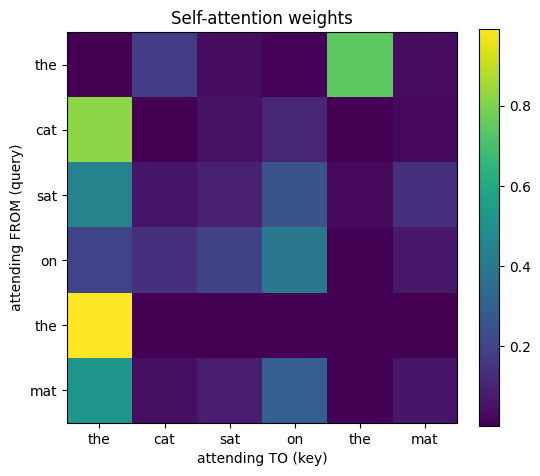

'the'  attends most to: ['the', 'cat']
'cat'  attends most to: ['the', 'on']
'sat'  attends most to: ['the', 'on']
'on'   attends most to: ['on', 'the']
'the'  attends most to: ['the', 'on']
'mat'  attends most to: ['the', 'on']


In [5]:
sentence = ["the", "cat", "sat", "on", "the", "mat"]
d = 8  # embedding dimension (tiny, just for illustration)

# In a real model these come from a trained embedding layer; here we use random
# vectors just to demonstrate the attention *mechanism* itself.
embeddings = np.random.randn(len(sentence), d)

def softmax(x, axis=-1):
    x = x - x.max(axis=axis, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)

Wq = np.random.randn(d, d) * 0.5
Wk = np.random.randn(d, d) * 0.5
Wv = np.random.randn(d, d) * 0.5

Q = embeddings @ Wq
K = embeddings @ Wk
V = embeddings @ Wv

scores = Q @ K.T / np.sqrt(d)          # raw compatibility scores
attn_weights = softmax(scores)          # normalised attention weights
output = attn_weights @ V               # weighted mix of Value vectors

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(attn_weights, cmap="viridis")
ax.set_xticks(range(len(sentence)), sentence)
ax.set_yticks(range(len(sentence)), sentence)
ax.set_xlabel("attending TO (key)")
ax.set_ylabel("attending FROM (query)")
ax.set_title("Self-attention weights")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

for i, tok in enumerate(sentence):
    top = np.argsort(-attn_weights[i])[:2]
    print(f"{tok!r:6} attends most to: {[sentence[j] for j in top]}")

Notice every row sums to 1 (it's a probability distribution over "which other tokens matter
for understanding this one"). With *random* weights the pattern is arbitrary — in a trained
model, `Wq`, `Wk`, `Wv` are learned so that, e.g., a pronoun attends strongly to the noun it
refers to. Real Transformers repeat this dozens of times in parallel ("multi-head attention")
across many stacked layers — but the arithmetic in this cell is the actual mechanism at the
heart of every LLM.

### 🧪 Try it yourself
Change `sentence` to a different 5–8 word sentence of your own, re-run the cell, and look at
the heatmap. Do any attention patterns look intuitive to you, or does it look mostly random?
(It should look random — we haven't trained the weights on anything!)

In [6]:
# TODO: try your own sentence and re-run the attention demo above with it
# sentence = ["your", "words", "go", "here"]

## 1.4 — LLMs and SLMs

Our bigram model from Section 1.1 is, in spirit, a **tiny "Small Language Model"**: it has a
small vocabulary, a handful of parameters (bigram counts), and no long-range context. Real
SLMs (Ministral-3B, Llama-3.2-1B) are vastly more capable, but the same trade-offs from the
deck apply: fewer parameters → cheaper, faster, easier to deploy, but less capable on complex
or unfamiliar tasks.

**Demo:** use our bigram model to *generate* text, and inspect its "parameter count" and
vocabulary size — a hands-on feel for why small models are small.

In [7]:
def generate(seed, n_words=20, seed_rng=0):
    rng = random.Random(seed_rng)
    out = [seed]
    for _ in range(n_words - 1):
        choices = bigram_counts.get(out[-1])
        if not choices:
            break
        next_word = rng.choices(list(choices.keys()), weights=choices.values())[0]
        out.append(next_word)
    return " ".join(out)

for seed in ["it", "alice", "the"]:
    print(f"{seed!r:8} -> {generate(seed, seed_rng=3)}")

n_params = sum(len(c) for c in bigram_counts.values())
print(f"\nThis toy 'SLM': {n_params} bigram counts as its 'parameters', "
      f"{len(set(words))}-word vocabulary.")
print("Compare: Llama-3.2-1B has ~1,000,000,000 parameters and a ~128k-token vocabulary.")

'it'     -> it was beginning to do once or no pictures or twice she had never before seen a white rabbit say
'alice'  -> alice was beginning to do once or no pictures or twice she had never before seen a white rabbit say
'the'    -> the age of times it and nothing particular to hear that she had never before seen a white rabbit say

This toy 'SLM': 347 bigram counts as its 'parameters', 203-word vocabulary.
Compare: Llama-3.2-1B has ~1,000,000,000 parameters and a ~128k-token vocabulary.


The generated text is grammatically loose and only ever "remembers" one word back — a
concrete illustration of *why* the deck's SLM comparison table lists lower accuracy and
narrower use cases for smaller models. A real SLM (millions–billions of parameters,
Transformer-based, trained on much more data) produces far more coherent text while still
being dramatically cheaper than a frontier LLM.

### 🧪 Try it yourself
Generate three completions from the same seed word using three different `seed_rng` values.
How much does the output vary? What does that tell you about the *reliability* of a model
this small, compared to what the deck says about LLM vs SLM accuracy trade-offs?

In [8]:
# TODO: generate 3 completions from the same seed with different seed_rng values
# for r in [1, 2, 3]:
#     print(generate("the", seed_rng=r))

## 1.5 — Tokenization

Following the deck's own progression: **character → numericalize → one-hot → word →
subword**. We'll use the exact same example sentence as the slides.

In [9]:
text = "Tokenizing text is a core task of NLP."

# --- 1. Character-level tokenization -------------------------------------------
char_tokens = list(text)
print("Character tokens:", char_tokens)

Character tokens: ['T', 'o', 'k', 'e', 'n', 'i', 'z', 'i', 'n', 'g', ' ', 't', 'e', 'x', 't', ' ', 'i', 's', ' ', 'a', ' ', 'c', 'o', 'r', 'e', ' ', 't', 'a', 's', 'k', ' ', 'o', 'f', ' ', 'N', 'L', 'P', '.']


In [10]:
# --- 2. Numericalization: characters -> integers --------------------------------
token2idx = {ch: idx for idx, ch in enumerate(sorted(set(char_tokens)))}
print("Vocabulary (unique characters):", token2idx)

input_ids = [token2idx[ch] for ch in char_tokens]
print("\ninput_ids:", input_ids)

Vocabulary (unique characters): {' ': 0, '.': 1, 'L': 2, 'N': 3, 'P': 4, 'T': 5, 'a': 6, 'c': 7, 'e': 8, 'f': 9, 'g': 10, 'i': 11, 'k': 12, 'n': 13, 'o': 14, 'r': 15, 's': 16, 't': 17, 'x': 18, 'z': 19}

input_ids: [5, 14, 12, 8, 13, 11, 19, 11, 13, 10, 0, 17, 8, 18, 17, 0, 11, 16, 0, 6, 0, 7, 14, 15, 8, 0, 17, 6, 16, 12, 0, 14, 9, 0, 3, 2, 4, 1]


In [11]:
# --- 3. One-hot encoding ---------------------------------------------------------
one_hot = np.eye(len(token2idx))[input_ids]
print("one_hot shape:", one_hot.shape, " (38 tokens x 20-character vocabulary)")
print(f"\nToken: {char_tokens[0]!r}")
print(f"Tensor index: {input_ids[0]}")
print(f"One-hot vector: {one_hot[0].astype(int)}")

one_hot shape: (38, 20)  (38 tokens x 20-character vocabulary)

Token: 'T'
Tensor index: 5
One-hot vector: [0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [12]:
# --- 4. Word-level tokenization ---------------------------------------------------
word_tokens = text.split()
print("Word tokens:", word_tokens)
print(f"Vocabulary size if we tokenized ALL of English by whitespace: "
      f"easily 1,000,000+ words (see deck 1.5 — that's the problem word tokenization runs into).")

Word tokens: ['Tokenizing', 'text', 'is', 'a', 'core', 'task', 'of', 'NLP.']
Vocabulary size if we tokenized ALL of English by whitespace: easily 1,000,000+ words (see deck 1.5 — that's the problem word tokenization runs into).


### Subword tokenization — training a real BPE tokenizer, locally

Modern LLMs use **subword tokenization** (e.g. WordPiece, BPE) — splitting rare words into
frequent sub-pieces so the vocabulary stays manageable while still handling any word,
misspelling or made-up term. Rather than downloading a pretrained tokenizer, we'll **train
our own small BPE tokenizer from scratch** on our corpus using HuggingFace's `tokenizers`
library — this runs entirely locally, no internet required.

In [13]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

with open("training_corpus.txt", "w") as f:
    f.write(TINY_TRAINING_TEXT + "\n")
    f.write(text + "\n")

bpe_tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
bpe_tokenizer.pre_tokenizer = Whitespace()
trainer = BpeTrainer(vocab_size=300, special_tokens=["[UNK]", "[CLS]", "[SEP]"])
bpe_tokenizer.train(["training_corpus.txt"], trainer)

print("Learned vocabulary size:", bpe_tokenizer.get_vocab_size())

encoded = bpe_tokenizer.encode(text)
print("\nSubword tokens:", encoded.tokens)
print("Token IDs:      ", encoded.ids)

# A word NOT seen during training gets split into familiar sub-pieces:
encoded2 = bpe_tokenizer.encode("universally")
print("\n'universally' (an unseen word) ->", encoded2.tokens)




Learned vocabulary size: 300

Subword tokens: ['Tok', 'en', 'i', 'z', 'ing', 't', 'ext', 'is', 'a', 'core', 't', 'as', 'k', 'of', 'NLP', '.']
Token IDs:       [268, 87, 44, 60, 66, 54, 229, 73, 36, 289, 54, 71, 46, 67, 261, 9]

'universally' (an unseen word) -> ['un', 'i', 'vers', 'ally']


Compare the three strategies on the same sentence:

| Strategy | Token count | Vocabulary needed |
| --- | --- | --- |
| Character | 38 tokens | 20 (tiny, but very long sequences) |
| Word | 8 tokens | unbounded (huge in practice) |
| Subword (BPE) | ~16 tokens | 300 here, ~30k–100k+ in production tokenizers |

This is exactly the "balanced middle ground" the deck describes — subword tokenization keeps
common words whole while still being able to represent *any* string by falling back to
smaller pieces.

### 🧪 Try it yourself
Encode a sentence containing a word that's definitely not in our tiny corpus (e.g. your own
name, or a made-up word like `"flibbertigibbet"`) with `bpe_tokenizer.encode(...)`. How does
it get split up? What does that tell you about how LLMs handle words they've never seen?

In [14]:
# TODO: encode your own sentence with bpe_tokenizer and print the tokens
# my_encoded = bpe_tokenizer.encode("your sentence here")
# print(my_encoded.tokens)

## 1.6 — Chunking & Context Management

LLMs (and RAG pipelines) can't process unlimited text at once, so long documents get split
into **chunks**. The deck covers three strategies — let's run all three on the same
paragraph (from *Alice's Adventures in Wonderland*) and compare.

In [15]:
alice_text = " ".join(ALICE_PARAGRAPH.split())  # normalise whitespace
print(f"Total length: {len(alice_text)} characters, {len(alice_text.split())} words\n")
print(alice_text[:300] + "...")

Total length: 1094 characters, 209 words

Alice was beginning to get very tired of sitting by her sister on the bank, and of having nothing to do: once or twice she had peeped into the book her sister was reading, but it had no pictures or conversations in it, "and what is the use of a book," thought Alice, "without pictures or conversation...


In [16]:
# --- Strategy 1: Fixed-size chunking (by characters, with overlap) --------------
def fixed_size_chunks(text, size=200, overlap=40):
    chunks, start = [], 0
    while start < len(text):
        chunks.append(text[start:start + size])
        start += size - overlap
    return chunks

fixed_chunks = fixed_size_chunks(alice_text, size=200, overlap=40)
print(f"Fixed-size chunking -> {len(fixed_chunks)} chunks\n")
for i, c in enumerate(fixed_chunks):
    print(f"  [{i}] ({len(c)} chars): {c[:65]}...")

Fixed-size chunking -> 7 chunks

  [0] (200 chars): Alice was beginning to get very tired of sitting by her sister on...
  [1] (200 chars): as reading, but it had no pictures or conversations in it, "and w...
  [2] (200 chars): dering in her own mind (as well as she could, for the hot day mad...
  [3] (200 chars):  the trouble of getting up and picking the daisies, when suddenly...
  [4] (200 chars): nor did Alice think it so very much out of the way to hear the Ra...
  [5] (200 chars): tch out of its waistcoat-pocket, and looked at it, and then hurri...
  [6] (134 chars):  a rabbit with either a waistcoat-pocket, or a watch to take out ...


In [17]:
# --- Strategy 2: Sentence-based ("semantic") chunking ---------------------------
def sentence_chunks(text):
    return re.split(r'(?<=[.!?]) +', text)

sent_chunks = sentence_chunks(alice_text)
print(f"Sentence-based chunking -> {len(sent_chunks)} chunks\n")
for i, c in enumerate(sent_chunks):
    print(f"  [{i}] ({len(c)} chars): {c[:65]}...")

Sentence-based chunking -> 4 chunks

  [0] (593 chars): Alice was beginning to get very tired of sitting by her sister on...
  [1] (140 chars): There was nothing so very remarkable in that; nor did Alice think...
  [2] (8 chars): Oh dear!...
  [3] (350 chars): I shall be late!" But when the Rabbit actually took a watch out o...


In [18]:
# --- Strategy 3: Hybrid (sentence-aware, capped at a max size) -----------------
def hybrid_chunks(sentences, max_chars=220):
    chunks, current = [], ""
    for s in sentences:
        if len(current) + len(s) + 1 <= max_chars:
            current = (current + " " + s).strip()
        else:
            if current:
                chunks.append(current)
            current = s
    if current:
        chunks.append(current)
    return chunks

hybrid = hybrid_chunks(sent_chunks, max_chars=220)
print(f"Hybrid chunking -> {len(hybrid)} chunks\n")
for i, c in enumerate(hybrid):
    print(f"  [{i}] ({len(c)} chars): {c[:70]}...")

Hybrid chunking -> 3 chunks

  [0] (593 chars): Alice was beginning to get very tired of sitting by her sister on the ...
  [1] (149 chars): There was nothing so very remarkable in that; nor did Alice think it s...
  [2] (350 chars): I shall be late!" But when the Rabbit actually took a watch out of its...


Notice chunk `[0]` under sentence-based chunking is **593 characters** — much bigger than the
others — because the first "sentence" contains embedded quotation marks and question marks
(`"and what is the use of a book," thought Alice, "without pictures or conversations?"`) that
our simple regex sentence-splitter doesn't handle perfectly. This is exactly the real-world
messiness the deck warns about: semantic chunking is more meaningful, but needs proper NLP
tooling to handle edge cases reliably. The hybrid strategy still doesn't split an
over-long sentence — a good next step (see task below) would be to fall back to fixed-size
splitting *within* an oversized sentence.

### 🧪 Try it yourself
Re-run `fixed_size_chunks` with `size=100, overlap=20`. Do more, smaller chunks make it more
or less likely that a single idea (e.g. "the Rabbit took a watch out of its
waistcoat-pocket") gets split across a chunk boundary? This is the exact trade-off the deck
discusses under RAG "chunk boundary split" issues.

In [19]:
# TODO: re-run fixed_size_chunks with size=100, overlap=20 and inspect the chunks
# small_chunks = fixed_size_chunks(alice_text, size=100, overlap=20)
# for i, c in enumerate(small_chunks):
#     print(f"[{i}] {c}")

## 1.7 — Embeddings & Vector Databases

An **embedding** turns text into a vector such that texts with similar *meaning* end up
close together in that vector space. Rather than downloading a large pretrained embedding
model, we'll **train a tiny Word2Vec model from scratch**, on our own corpus, using `gensim`
— entirely offline. It's much smaller than a production embedding model, but demonstrates the
exact same idea: word co-occurrence patterns become geometry.

In [20]:
from gensim.models import Word2Vec

def tokenize(text):
    return re.findall(r"[a-z']+", text.lower())

training_sentences = [tokenize(t) for _, _, t in OPENING_LINES] + [tokenize(TINY_TRAINING_TEXT)]

w2v = Word2Vec(sentences=training_sentences, vector_size=50, window=4,
                min_count=1, sg=1, epochs=200, seed=42)

print("Vocabulary size:", len(w2v.wv))
print("First 5 dimensions of the vector for 'money':", w2v.wv["money"][:5])

Vocabulary size: 203
First 5 dimensions of the vector for 'money': [-0.2510971  -0.03054347 -0.30375156  0.22502926 -0.44097233]


In [21]:
def sentence_embedding(text, model):
    toks = [t for t in tokenize(text) if t in model.wv]
    if not toks:
        return np.zeros(model.vector_size)
    return np.mean([model.wv[t] for t in toks], axis=0)

def cosine_sim(a, b):
    return a @ b / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-9)

doc_embeddings = np.array([sentence_embedding(t, w2v) for _, _, t in OPENING_LINES])
print("Document embeddings shape:", doc_embeddings.shape,
      "(8 opening lines x 50-dimensional vectors)")

query = "a wealthy gentleman looking for a wife"
q_emb = sentence_embedding(query, w2v)

sims = [cosine_sim(q_emb, d) for d in doc_embeddings]
ranked = sorted(zip(sims, OPENING_LINES), key=lambda x: -x[0])

print(f"\nQuery: {query!r}\nRanked by semantic similarity:\n")
for sim, (title, author, snippet) in ranked:
    print(f"  {sim:.3f}  {title} ({author})")

Document embeddings shape: (8, 50) (8 opening lines x 50-dimensional vectors)

Query: 'a wealthy gentleman looking for a wife'
Ranked by semantic similarity:

  0.890  Pride and Prejudice (Jane Austen)
  0.714  Moby-Dick (Herman Melville)
  0.457  The Adventures of Sherlock Holmes (Arthur Conan Doyle)
  0.451  A Tale of Two Cities (Charles Dickens)
  0.434  War and Peace (Leo Tolstoy)
  0.399  Frankenstein (Mary Shelley)
  0.387  Dracula (Bram Stoker)
  0.383  Alice's Adventures in Wonderland (Lewis Carroll)


Notice *Pride and Prejudice* ranks highest even though the query shares almost no exact
words with it ("wealthy gentleman... wife" vs "a single man in possession of a good
fortune... in want of a wife") — this is **semantic** similarity, not keyword matching. This
is the entire premise behind RAG (Section 2.3): retrieve by *meaning*, not exact text match.

### Storing embeddings in a vector database

Now let's put these vectors into an actual local vector database — **Chroma** — the same
kind of tool used in production RAG pipelines, just running in-memory here.

In [22]:
import chromadb

client = chromadb.Client()  # in-memory, no network calls
collection = client.create_collection(name="opening_lines")

ids = [f"doc{i}" for i in range(len(OPENING_LINES))]
documents = [t for _, _, t in OPENING_LINES]
embeddings = [sentence_embedding(t, w2v).tolist() for _, _, t in OPENING_LINES]
metadatas = [{"title": title, "author": author} for title, author, _ in OPENING_LINES]

collection.add(ids=ids, documents=documents, embeddings=embeddings, metadatas=metadatas)
print("Vectors stored in Chroma:", collection.count())

results = collection.query(query_embeddings=[q_emb.tolist()], n_results=3)
print(f"\nTop 3 nearest neighbours for: {query!r}\n")
for doc, meta, dist in zip(results["documents"][0], results["metadatas"][0],
                            results["distances"][0]):
    print(f"  distance={dist:.3f}  {meta['title']} ({meta['author']})")
    print(f"    \"{doc[:70]}...\"")

Vectors stored in Chroma: 8

Top 3 nearest neighbours for: 'a wealthy gentleman looking for a wife'

  distance=1.315  Pride and Prejudice (Jane Austen)
    "It is a truth universally acknowledged, that a single man in possessio..."
  distance=3.094  Moby-Dick (Herman Melville)
    "Call me Ishmael. Some years ago, having little or no money in my purse..."
  distance=5.799  Alice's Adventures in Wonderland (Lewis Carroll)
    "Alice was beginning to get very tired of sitting by her sister on the ..."


This is a miniature version of the exact RAG pipeline the deck describes in 2.3: **embed
documents → store in a vector DB → embed the query → similarity search → retrieve top-k**.
In Part 2 of this course we'll plug an actual LLM on top of this retrieval step to generate
grounded answers.

### 🧪 Try it yourself
Write two of your own queries (as strings) related to different opening lines above (e.g.
something about a ship voyage, or something about wealthy families), embed them with
`sentence_embedding(...)`, and query the `collection` for the top 3 matches each. Do the
results match what you'd expect?

In [23]:
# TODO: try your own queries against the vector database
# my_query = "a long sea voyage"
# my_q_emb = sentence_embedding(my_query, w2v).tolist()
# results = collection.query(query_embeddings=[my_q_emb], n_results=3)
# for doc, meta in zip(results["documents"][0], results["metadatas"][0]):
#     print(meta["title"], "-", doc[:60])

## Wrap-up

In this notebook you:
- Built a tiny **language model** from word-frequency counts (1.1)
- Saw the historical path to Transformers (1.2)
- Implemented **self-attention** from the actual formula (1.3)
- Compared a toy "SLM" to what real LLMs/SLMs look like (1.4)
- Walked character → word → **subword tokenization**, training your own BPE tokenizer (1.5)
- Compared three **chunking** strategies on a real paragraph (1.6)
- Trained your own **embeddings**, ran semantic search, and stored vectors in a real
  **vector database** (1.7)

**Next up — Part 2 (`02_practical_use_of_llms.ipynb`):** prompting techniques, generation
parameters, a full RAG pipeline, fine-tuning & LoRA, and guardrails / human-in-the-loop.